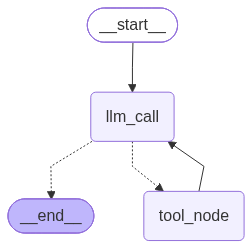

[tool_node] 调用工具 add，结果: 7
[retry] get_weather 第 1 次失败: 网络波动，第 1 次调用失败
[retry] get_weather 第 2 次失败: 网络波动，第 2 次调用失败
[tool_node] 调用工具 get_weather，结果: The weather in 北京 is sunny with a high of 25°C.
================================ Human Message =================================

Please add 3 and 4.
================================ Human Message =================================

北京今天天气怎么样？
================================== Ai Message ==================================

I'll help you with both requests.
Tool Calls:
  add (call_00_vZSSEXssU4S6M0HfBTTA4768)
 Call ID: call_00_vZSSEXssU4S6M0HfBTTA4768
  Args:
    a: 3
    b: 4
  get_weather (call_01_KMra7x6sK28rNRt5Ykv66099)
 Call ID: call_01_KMra7x6sK28rNRt5Ykv66099
  Args:
    city: 北京
================================= Tool Message =================================

7
================================= Tool Message =================================

The weather in 北京 is sunny with a high of 25°C.
================================== Ai Messag

In [22]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()

# 1. Define tools and model
model = init_chat_model("deepseek-v4-flash", temperature=0)

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add two numbers."""
    return a + b

@tool
def divide(a: int, b: int) -> int:
    """Divide two numbers."""
    return a / b

@tool
def subtract(a: int, b: int) -> int:
    """Subtract two numbers."""
    return a - b

# 单个工具调用级别的重试装饰器（只重试失败的那个工具，不影响同一节点里的其他工具）
import time
from functools import wraps

def retry(max_attempts: int = 3, initial_interval: float = 1.0):
    """在单个工具内部重试。"""
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            for attempt in range(1, max_attempts + 1):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    print(f"[retry] {func.__name__} 第 {attempt} 次失败: {e}")
                    if attempt == max_attempts:
                        raise
                    time.sleep(initial_interval)
        return wrapper
    return decorator

_weather_attempts = 0

@tool
@retry(max_attempts=3, initial_interval=1.0)
def get_weather(city: str) -> str:
    """Get the weather for a city."""
    global _weather_attempts
    _weather_attempts += 1

    # 模拟网络波动：前两次抛异常，第三次才成功
    if _weather_attempts < 3:
        raise ConnectionError(f"网络波动，第 {_weather_attempts} 次调用失败")

    # For demonstration purposes, we'll return a static response.
    # In a real implementation, you would call a weather API here.
    return f"The weather in {city} is sunny with a high of 25°C."

tools = [multiply, add, divide, subtract, get_weather]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

# 2. Define state

from langchain.messages import AnyMessage
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
# import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    llm_calls: int

# 3. Define model node

from langchain.messages import SystemMessage

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages":[
            model_with_tools.invoke(
                [SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")] + state["messages"]
            )
        ],
        "llm_calls": state.get("llm_calls", 0) + 1
    }


# 4. Define tool node

from langchain.messages import ToolMessage

def tool_node(state: MessagesState):
    """Performs the tool call"""
    result = []

    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        print(f"[tool_node] 调用工具 {tool_call['name']}，结果: {observation}")
        result.append(ToolMessage(content=str(observation),tool_call_id=tool_call["id"]))
    return {"messages": result}

# Step 5: Define logic to determine whether to end

from langgraph.graph import END, START, StateGraph
from typing import Literal

def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""
    messages = state["messages"]
    last_message = messages[-1] if messages else None

    # if the llm makes a tool call, then peformance the tool call, otherwise end the loop
    if last_message.tool_calls:
        return "tool_node"
    else:
        return END

# Step 6: Build agent


agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
# Add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

from IPython.display import Image, display

# Show the agent in notebook
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
# from rich import print as rprint

messages = [HumanMessage(content="Please add 3 and 4."),HumanMessage(content="北京今天天气怎么样？")]
messages = agent.invoke({"messages": messages})

for m in messages["messages"]:
    m.pretty_print()

print(f"LLM calls: {messages['llm_calls']}")

# rprint("messages:", messages)
